序列模型

数据不是独立的，而是“依赖历史”的，所以我们需要序列模型。
序列建模：
$$x_t \sim P(x_t \mid x_{t-1}, \ldots, x_1).$$
用过去所有信息预测当前。

自回归模型

用过去所有信息预测当前

方法一：有限窗口，只看最近τ个，使得输入维度固定，可用普通神经网络训练。
方法二：隐变量模型（RNN思想），产生了基于$\hat{x}_t = P(x_t \mid h_{t})$估计$x_t$，
以及公式$h_t = g(h_{t-1}, x_{t-1})$更新的模型。ht是对过去的“压缩记忆”，不用保存全部历史。


马尔可夫模型

假设未来只依赖“最近的过去”

$P(x_{t+1} \mid x_{t-1})$：


$$
\begin{aligned}
P(x_{t+1} \mid x_{t-1})
&= \frac{\sum_{x_t} P(x_{t+1}, x_t, x_{t-1})}{P(x_{t-1})}\\
&= \frac{\sum_{x_t} P(x_{t+1} \mid x_t, x_{t-1}) P(x_t, x_{t-1})}{P(x_{t-1})}\\
&= \sum_{x_t} P(x_{t+1} \mid x_t) P(x_t \mid x_{t-1})
\end{aligned}
$$


因果关系

时间是单向的，未来不能影响过去。

解释$P(x_{t+1} \mid x_t)$应该比解释$P(x_t \mid x_{t+1})$更容易。
例如，在某些情况下，对于某些可加性噪声$\epsilon$，
显然我们可以找到$x_{t+1} = f(x_t) + \epsilon$，
而反之则不行

训练

生成一些数据：使用正弦函数和一些可加性噪声来生成序列数据。

In [1]:
%matplotlib inline
import torch
from torch import nn

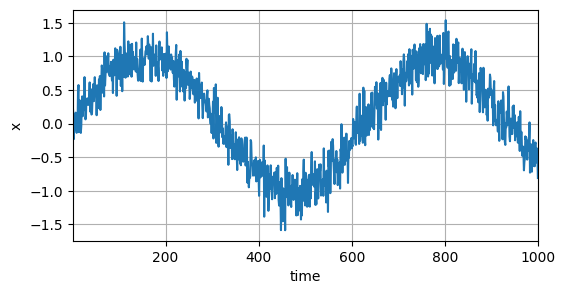

In [2]:
import torch
import matplotlib.pyplot as plt

# 生成数据
T = 1000  # 总共产生1000个点
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))

# 画图
plt.figure(figsize=(6, 3))
plt.plot(time.numpy(), x.numpy())
plt.xlabel('time')
plt.ylabel('x')
plt.xlim(1, 1000)
plt.grid()
plt.show()

将这个序列转换为模型的特征－标签对。
基于嵌入维度$\tau$，我们将数据映射为数据对$y_t = x_t$
和$\mathbf{x}_t = [x_{t-\tau}, \ldots, x_{t-1}]$。


In [3]:
tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader

batch_size, n_train = 16, 600

# 构造数据集（只用前 n_train 个样本）
train_dataset = TensorDataset(features[:n_train], labels[:n_train])

# 构造 DataLoader
train_iter = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # 等价于 is_train=True
)

使用一个拥有两个全连接层的多层感知机，ReLU激活函数和平方损失。

In [5]:
# 初始化网络权重的函数
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

# 一个简单的多层感知机
def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))
    net.apply(init_weights)
    return net

# 平方损失。注意：MSELoss计算平方误差时不带系数1/2
loss = nn.MSELoss(reduction='none')

训练模型

In [7]:
import torch

def evaluate_loss(net, data_iter, loss):
    total_loss = 0.0
    total_num = 0

    net.eval()  # 评估模式
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += l.sum().item()
            total_num += y.numel()
    net.train()  # 恢复训练模式

    return total_loss / total_num


def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr=lr)

    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()


        epoch_loss = evaluate_loss(net, train_iter, loss)
        print(f'epoch {epoch + 1}, loss: {epoch_loss:.6f}')


# 训练
net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch 1, loss: 0.069019
epoch 2, loss: 0.057598
epoch 3, loss: 0.051760
epoch 4, loss: 0.051181
epoch 5, loss: 0.053720


预测

训练损失很小，因此我们期望模型能有很好的工作效果：检查模型预测下一个时间步的能力，即单步预测。

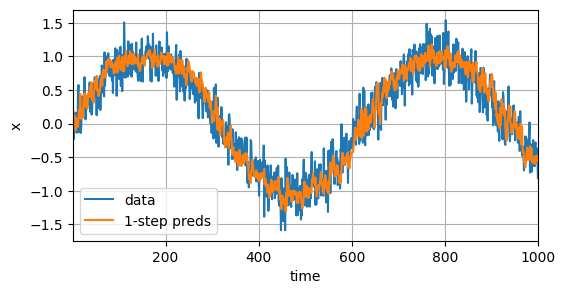

In [8]:
import matplotlib.pyplot as plt

# 预测
onestep_preds = net(features)

# 画图
plt.figure(figsize=(6, 3))

# 原始数据
plt.plot(time.numpy(), x.detach().numpy(), label='data')

# 预测数据（注意从 tau 开始）
plt.plot(time[tau:].numpy(),
         onestep_preds.detach().numpy(),
         label='1-step preds')

plt.xlabel('time')
plt.ylabel('x')
plt.xlim(1, 1000)
plt.legend()
plt.grid()

plt.show()

对于直到$x_t$的观测序列，其在时间步$t+k$处的预测输出$\hat{x}_{t+k}$
称为$k$*步预测*（$k$-step-ahead-prediction）。
由于我们的观察已经到了$x_{604}$，它的$k$步预测是$\hat{x}_{604+k}$。

In [9]:
multistep_preds = torch.zeros(T)
multistep_preds[: n_train + tau] = x[: n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(
        multistep_preds[i - tau:i].reshape((1, -1)))

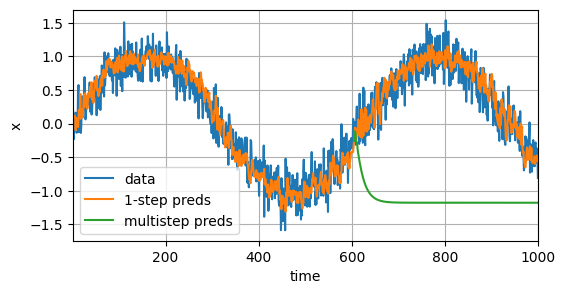

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))

# 原始数据
plt.plot(time.numpy(),
         x.detach().numpy(),
         label='data')

# 一步预测
plt.plot(time[tau:].numpy(),
         onestep_preds.detach().numpy(),
         label='1-step preds')

# 多步预测（从训练数据之后开始）
plt.plot(time[n_train + tau:].numpy(),
         multistep_preds[n_train + tau:].detach().numpy(),
         label='multistep preds')

plt.xlabel('time')
plt.ylabel('x')
plt.xlim(1, 1000)
plt.legend()
plt.grid()

plt.show()

绿线的预测显然并不理想。 经过几个预测步骤之后，预测的结果很快就会衰减到一个常数。

效果差的原因：假设在步骤$1$之后，我们积累了一些错误$\epsilon_1 = \bar\epsilon$。
于是，步骤$2$的输入被扰动了$\epsilon_1$，
结果积累的误差是依照次序的$\epsilon_2 = \bar\epsilon + c \epsilon_1$，
其中$c$为某个常数，后面的预测误差依此类推。

基于$k = 1, 4, 16, 64$，通过对整个序列预测的计算，
让我们[**更仔细地看一下$k$步预测**]的困难。


In [11]:
max_steps = 64

In [12]:
features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
# 列i（i<tau）是来自x的观测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau):
    features[:, i] = x[i: i + T - tau - max_steps + 1]

# 列i（i>=tau）是来自（i-tau+1）步的预测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

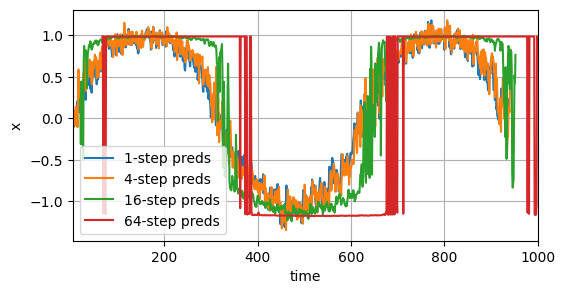

In [13]:
import matplotlib.pyplot as plt

steps = (1, 4, 16, 64)

plt.figure(figsize=(6, 3))

for i in steps:
    plt.plot(
        time[tau + i - 1: T - max_steps + i].numpy(),
        features[:, (tau + i - 1)].detach().numpy(),
        label=f'{i}-step preds'
    )

plt.xlabel('time')
plt.ylabel('x')
plt.xlim(5, 1000)
plt.legend()
plt.grid()

plt.show()